# IMPORTAR MATRIZ M

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF as skNMF
import os
%matplotlib inline

In [9]:
sys.path.insert(0, r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise")

BASE = r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\Analisis Quique"
SEED = 42

ruta = os.path.join(BASE, "data", "PCAWG_2583_SBS96.txt")
M_df_full = pd.read_csv(ruta, sep='\t', index_col=0)
coad_cols = [col for col in M_df_full.columns if col.startswith("LUAD") or col.startswith("LUSC")]
M_df = M_df_full[coad_cols]
M = M_df.values.astype(float)
n_mut, n_tum = M.shape

ruta_pulmon = os.path.join(BASE, "data", "PULMON_84.txt")
M_df.to_csv(ruta_pulmon, sep='\t')

print(f"M: {M.shape}")

M: (96, 84)


In [10]:
M_df

,LUAD.US_SP50827,LUAD.US_SP50263,LUAD.US_SP50317,LUAD.US_SP54113,LUSC.US_SP56537,LUAD.US_SP50406,LUSC.US_SP57586,LUAD.US_SP51824,LUAD.US_SP55387,LUAD.US_SP52779,...,LUAD.US_SP52667,LUSC.US_SP57450,LUSC.US_SP57846,LUSC.US_SP58612,LUSC.US_SP56821,LUAD.US_SP51446,LUAD.US_SP50592,LUAD.US_SP53073,LUSC.US_SP58882,LUSC.US_SP57189
MutationType,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,1727,217,331,4163,1691,13,1168,601,969,1631,...,1304,437,1165,879,1034,119,95,723,528,4590
A[C>A]C,1164,136,183,2514,984,5,668,413,546,957,...,917,249,791,556,603,94,50,507,295,2688
A[C>A]G,429,38,35,998,376,0,262,156,197,437,...,359,86,346,217,234,21,16,173,103,1014
A[C>A]T,1167,130,219,2547,1093,7,699,401,643,1074,...,906,263,748,478,653,73,52,452,320,2800
A[C>G]A,413,106,113,1377,510,5,412,201,260,305,...,310,205,378,294,337,23,26,162,212,1503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T[T>C]T,220,109,111,648,321,6,420,164,112,168,...,128,208,277,247,266,61,84,214,404,761
T[T>G]A,86,36,39,286,134,2,184,70,39,94,...,63,78,119,85,117,22,25,46,128,299
T[T>G]C,35,37,30,128,58,1,82,38,31,39,...,36,44,69,54,43,15,15,47,81,93


In [11]:
RESIDUALS_DIR = r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\SigProfilerExtractor\_residuals"
K_FILE = r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\SigProfilerExtractor\_current_k.txt"

os.makedirs(RESIDUALS_DIR, exist_ok=True)
print("Rutas OK")

Rutas OK


In [15]:
U_POR_K_DIR = os.path.join(BASE, "resultados", "extraccion_pulmon_1_15", "SBS96", "U_por_K")

for k in range(1, 16):
    U_df = pd.read_csv(os.path.join(U_POR_K_DIR, f"U_K{k}.csv"), index_col=0)
    U_arr = U_df.values.astype(float)
    SA = M - U_arr
    
    np.save(os.path.join(RESIDUALS_DIR, f"SA_k{k}.npy"), SA)
    np.save(os.path.join(RESIDUALS_DIR, f"U_k{k}.npy"), U_arr)
    
    print(f"K={k} — media U: {U_arr.mean():.6f} — guardado OK")

print("Pre-cálculo completado")

K=1 — media U: -0.000003 — guardado OK
K=2 — media U: 0.000007 — guardado OK
K=3 — media U: -0.000003 — guardado OK
K=4 — media U: 0.000001 — guardado OK
K=5 — media U: 0.000003 — guardado OK
K=6 — media U: 0.000003 — guardado OK
K=7 — media U: -0.000000 — guardado OK
K=8 — media U: -0.000001 — guardado OK
K=9 — media U: 0.000001 — guardado OK
K=10 — media U: -0.000001 — guardado OK
K=11 — media U: 0.000002 — guardado OK
K=12 — media U: -0.000000 — guardado OK
K=13 — media U: 0.000003 — guardado OK
K=14 — media U: -0.000000 — guardado OK
K=15 — media U: 0.000000 — guardado OK
Pre-cálculo completado


In [17]:
from SigProfilerExtractor import sigpro as sig

output_residual = os.path.join(BASE, "resultados", "extraccion_residual")
os.makedirs(output_residual, exist_ok=True)

sig.sigProfilerExtractor(
    input_type="matrix",
    output=output_residual,
    input_data=ruta_pulmon,
    reference_genome="GRCh37",
    minimum_signatures=1,
    maximum_signatures=15,
    nmf_replicates=100
)


************** Reported Current Memory Use: 0.39 GB *****************

Extracting signature 1 for mutation type 96
The matrix normalizing cutoff is 75057


Time taken to collect 100 iterations for 1 signatures is 125.77 seconds
Optimization time is 10.61457109451294 seconds
The reconstruction error is 0.4124, average process stability is 1.0 and 
the minimum process stability is 1.0 for 1 signatures


Extracting signature 2 for mutation type 96
The matrix normalizing cutoff is 75057


Time taken to collect 100 iterations for 2 signatures is 172.02 seconds
Optimization time is 10.285985946655273 seconds
The reconstruction error is 0.2131, average process stability is 0.96 and 
the minimum process stability is 0.94 for 2 signatures


Extracting signature 3 for mutation type 96
The matrix normalizing cutoff is 75057


Time taken to collect 100 iterations for 3 signatures is 304.21 seconds
Optimization time is 11.034314632415771 seconds
The reconstruction error is 0.1458, average process 

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   11.0s
[Parallel(n_jobs=12)]: Done  78 out of  84 | elapsed:   11.1s remaining:    0.8s
[Parallel(n_jobs=12)]: Done  84 out of  84 | elapsed:   11.1s finished



 Decomposing De Novo Signatures  .....
Decompositon Plot:SBS96A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (5685.05/s) 
Decompositon Plot:SBS96B |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (4859.09/s) 
Decompositon Plot:SBS96C |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (5750.43/s) 

 Assigning decomposed signature


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  61 out of  84 | elapsed:    0.6s remaining:    0.2s
[Parallel(n_jobs=12)]: Done  78 out of  84 | elapsed:    0.7s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  84 out of  84 | elapsed:    0.7s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 


# NUEVO REMUESTREO

# HACER EL NMF CON SIPROFILEXTRACTOR

In [ ]:
# from SigProfilerExtractor import sigpro as sig
# import os

# output = os.path.join(BASE, "resultados", "extraccion_pulmon")

# if os.path.exists(os.path.join(output, "SBS96")):
#     print("Extracción ya realizada, saltando.")
# else:
#     os.makedirs(output, exist_ok=True)
#     sig.sigProfilerExtractor(
#         input_type="matrix",
#         output=output,
#         input_data=ruta_pulmon,
#         reference_genome="GRCh37",
#         minimum_signatures=1,
#         maximum_signatures=10,
#         nmf_replicates=100
#     )

Extracción ya realizada, saltando.


# RESULTADOS DE NOVO

Matrices A y S

In [18]:
base_denovo = os.path.join(BASE, "resultados", "extraccion_residual", "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution")

# Cargar S y A de novo
S_denovo_df = pd.read_csv(base_denovo + r"\Signatures\SBS96_De-Novo_Signatures.txt", sep="\t", index_col=0)
A_denovo_df = pd.read_csv(base_denovo + r"\Activities\SBS96_De-Novo_Activities_refit.txt", sep="\t", index_col=0)
S_sem_df    = pd.read_csv(base_denovo + r"\Signatures\SBS96_De-Novo_Signatures_SEM_Error.txt", sep="\t", index_col=0)

print("S de novo:", S_denovo_df.shape)
print("A de novo:", A_denovo_df.shape)
print("SEM de S: ", S_sem_df.shape)

S_denovo_df.head()

S de novo: (96, 3)
A de novo: (84, 3)
SEM de S:  (96, 3)


,SBS96A,SBS96B,SBS96C
MutationType,,,
A[C>A]A,0.046720,0.014195,0.006876
A[C>A]C,0.028920,0.007641,0.004563
A[C>A]G,0.011600,0.001920,0.000911
A[C>A]T,0.030992,0.007442,0.004339
A[C>G]A,0.011562,0.009231,0.003644


Firmas Asignadas

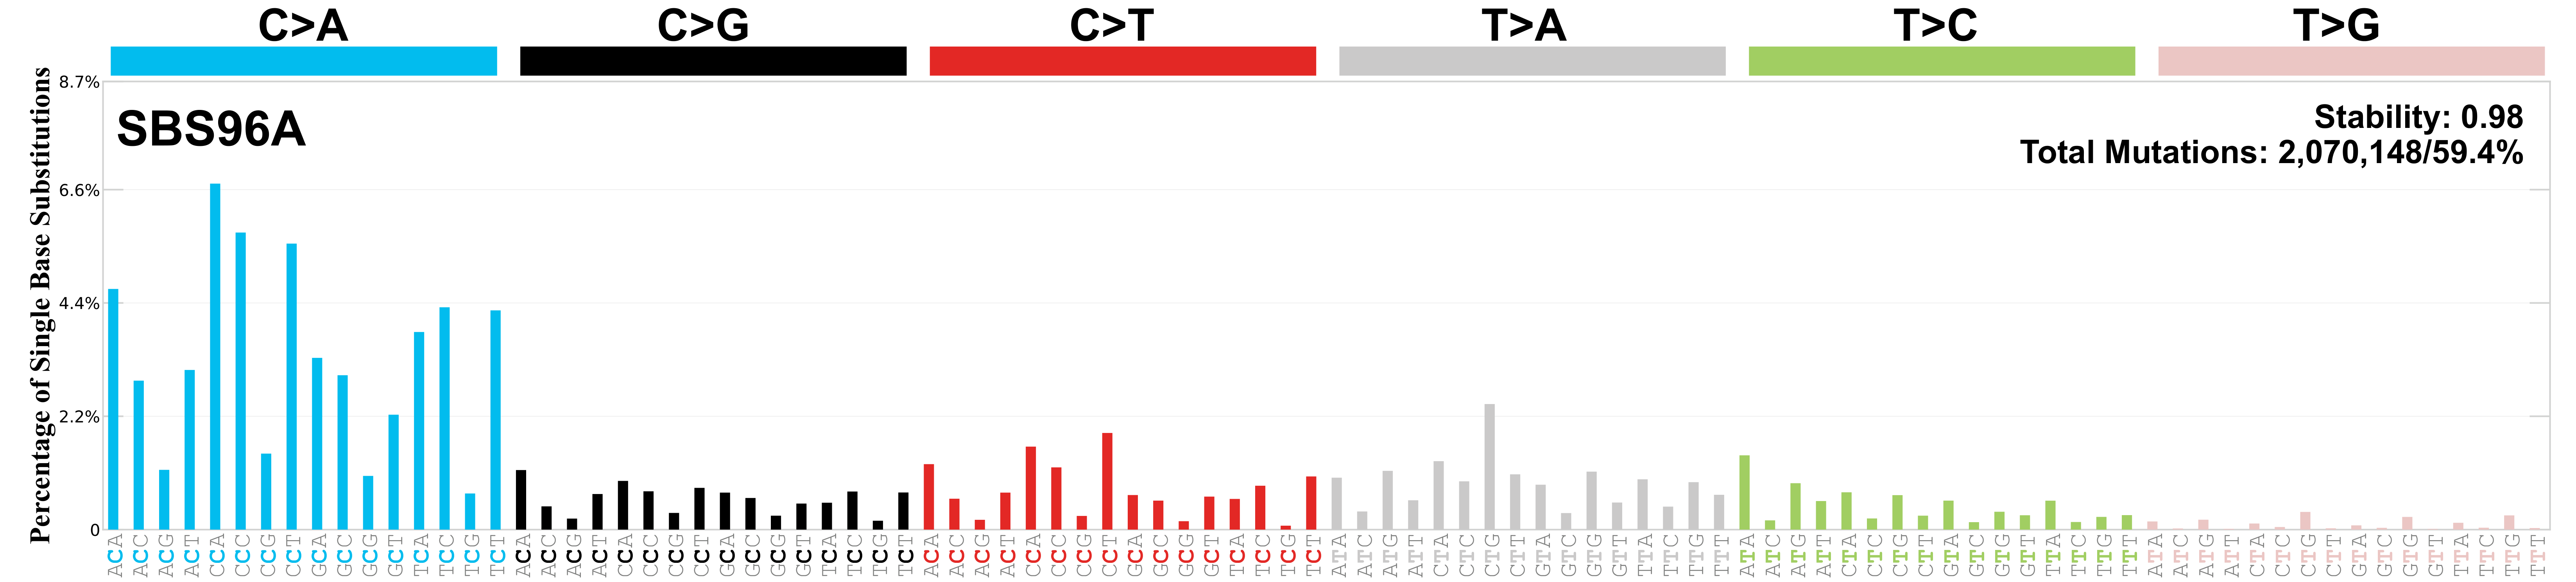

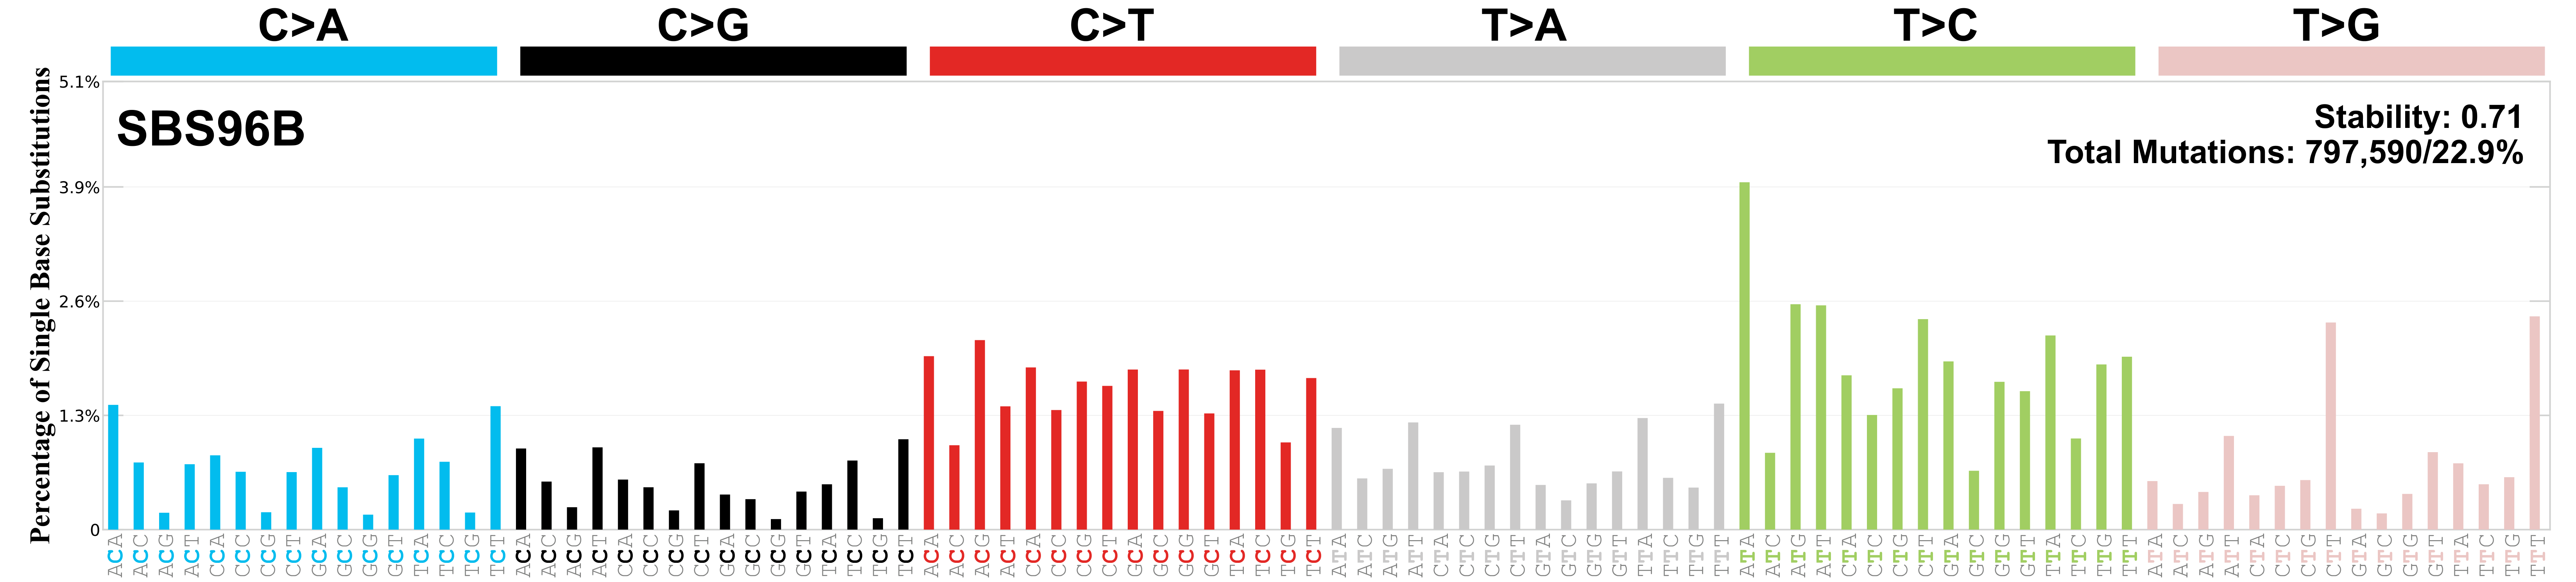

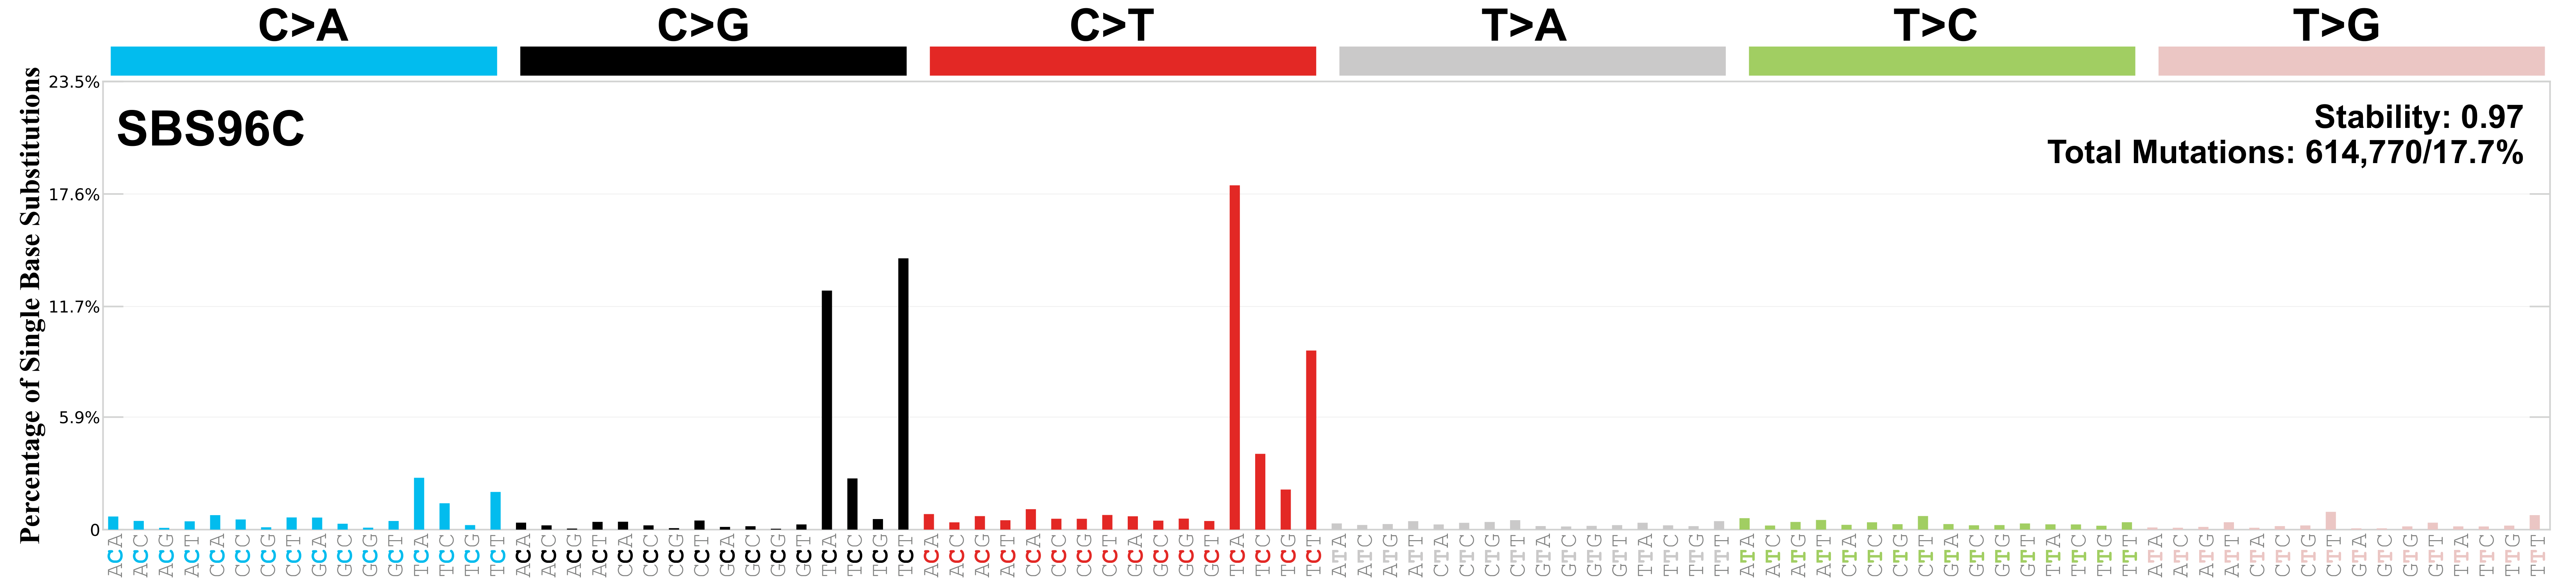

In [19]:
from IPython.display import Image
import fitz  # pip install pymupdf

# Convertir primera página del PDF a imagen
pdf_path = base_denovo + r"\Signatures\SBS_96_plots_SBS96_De-Novo.pdf"
doc = fitz.open(pdf_path)

for i, page in enumerate(doc):
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

Explicación del número de firmas

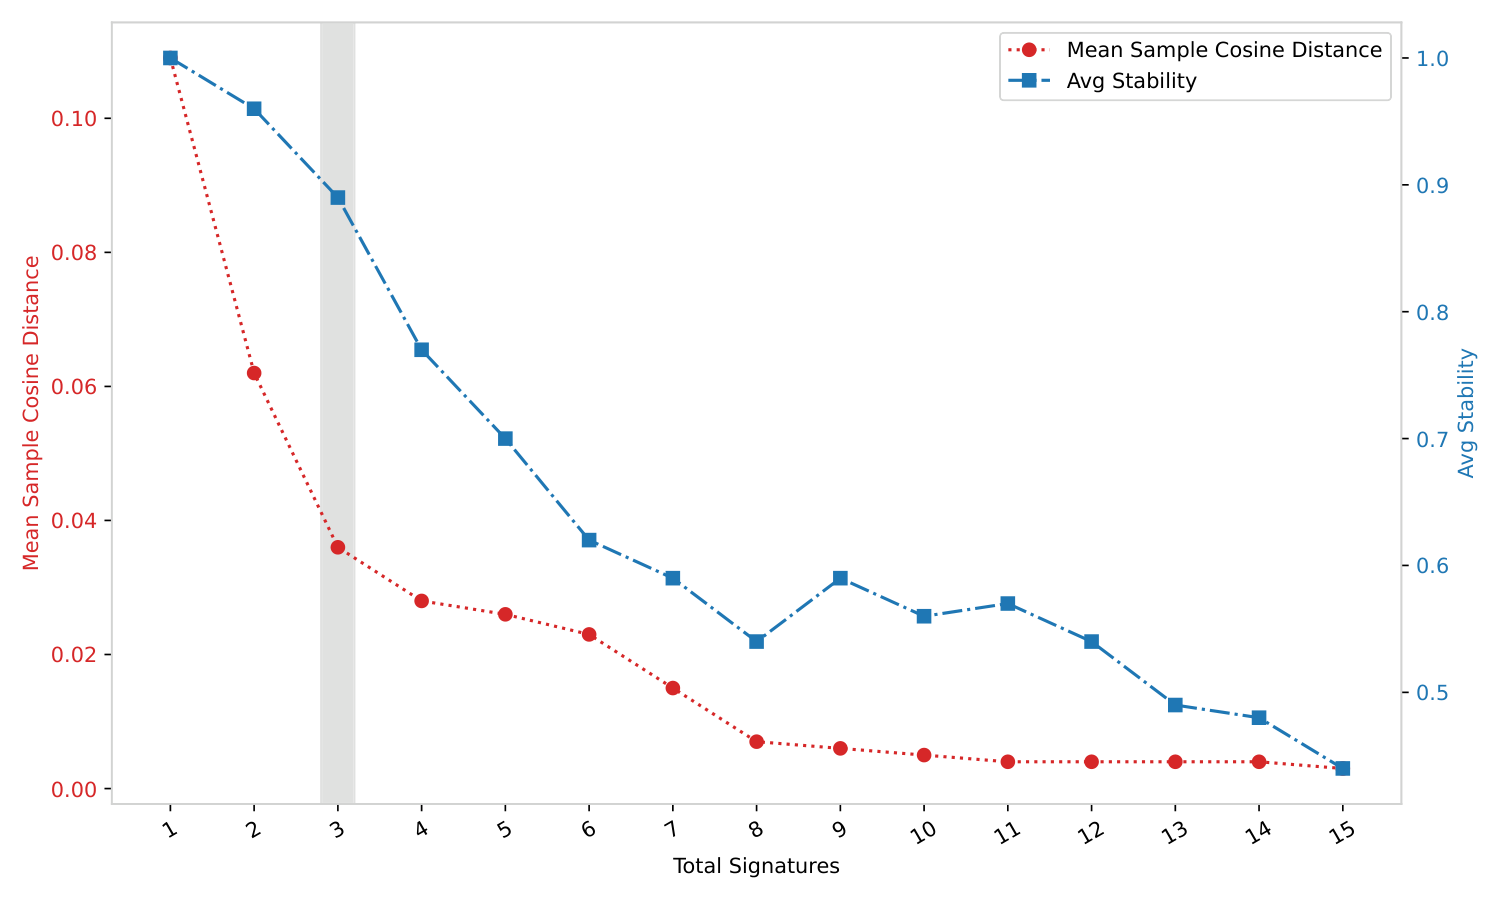

In [21]:
base_output = output_residual  # = os.path.join(BASE, "resultados", "extraccion_pulmon")

pdf_path = os.path.join(base_output, "SBS96", "SBS96_selection_plot.pdf")
doc = fitz.open(pdf_path)
for page in doc:
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

Qué firmas se han detectado en cada tumor (146 tumores repartidos en 3 paginas)

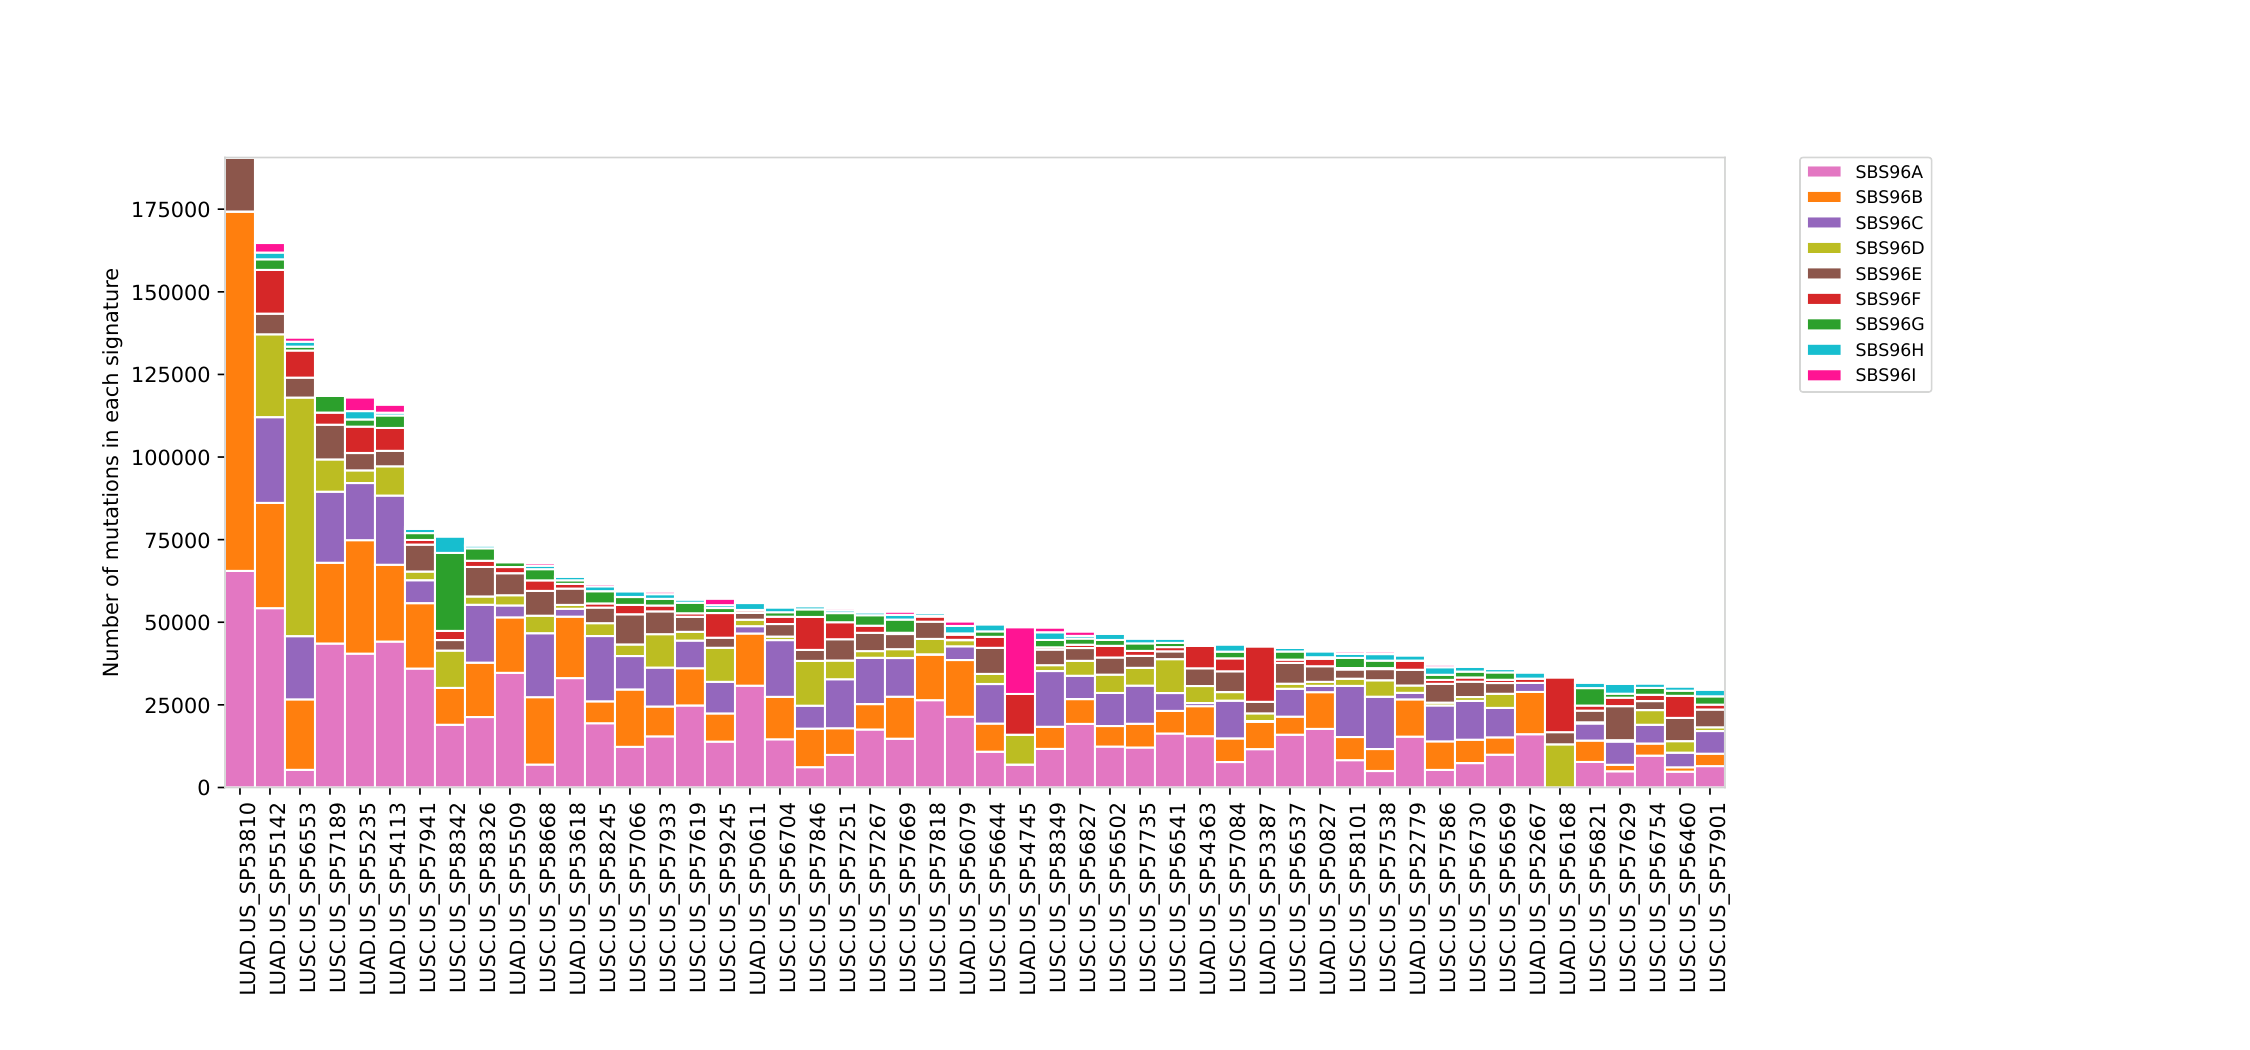

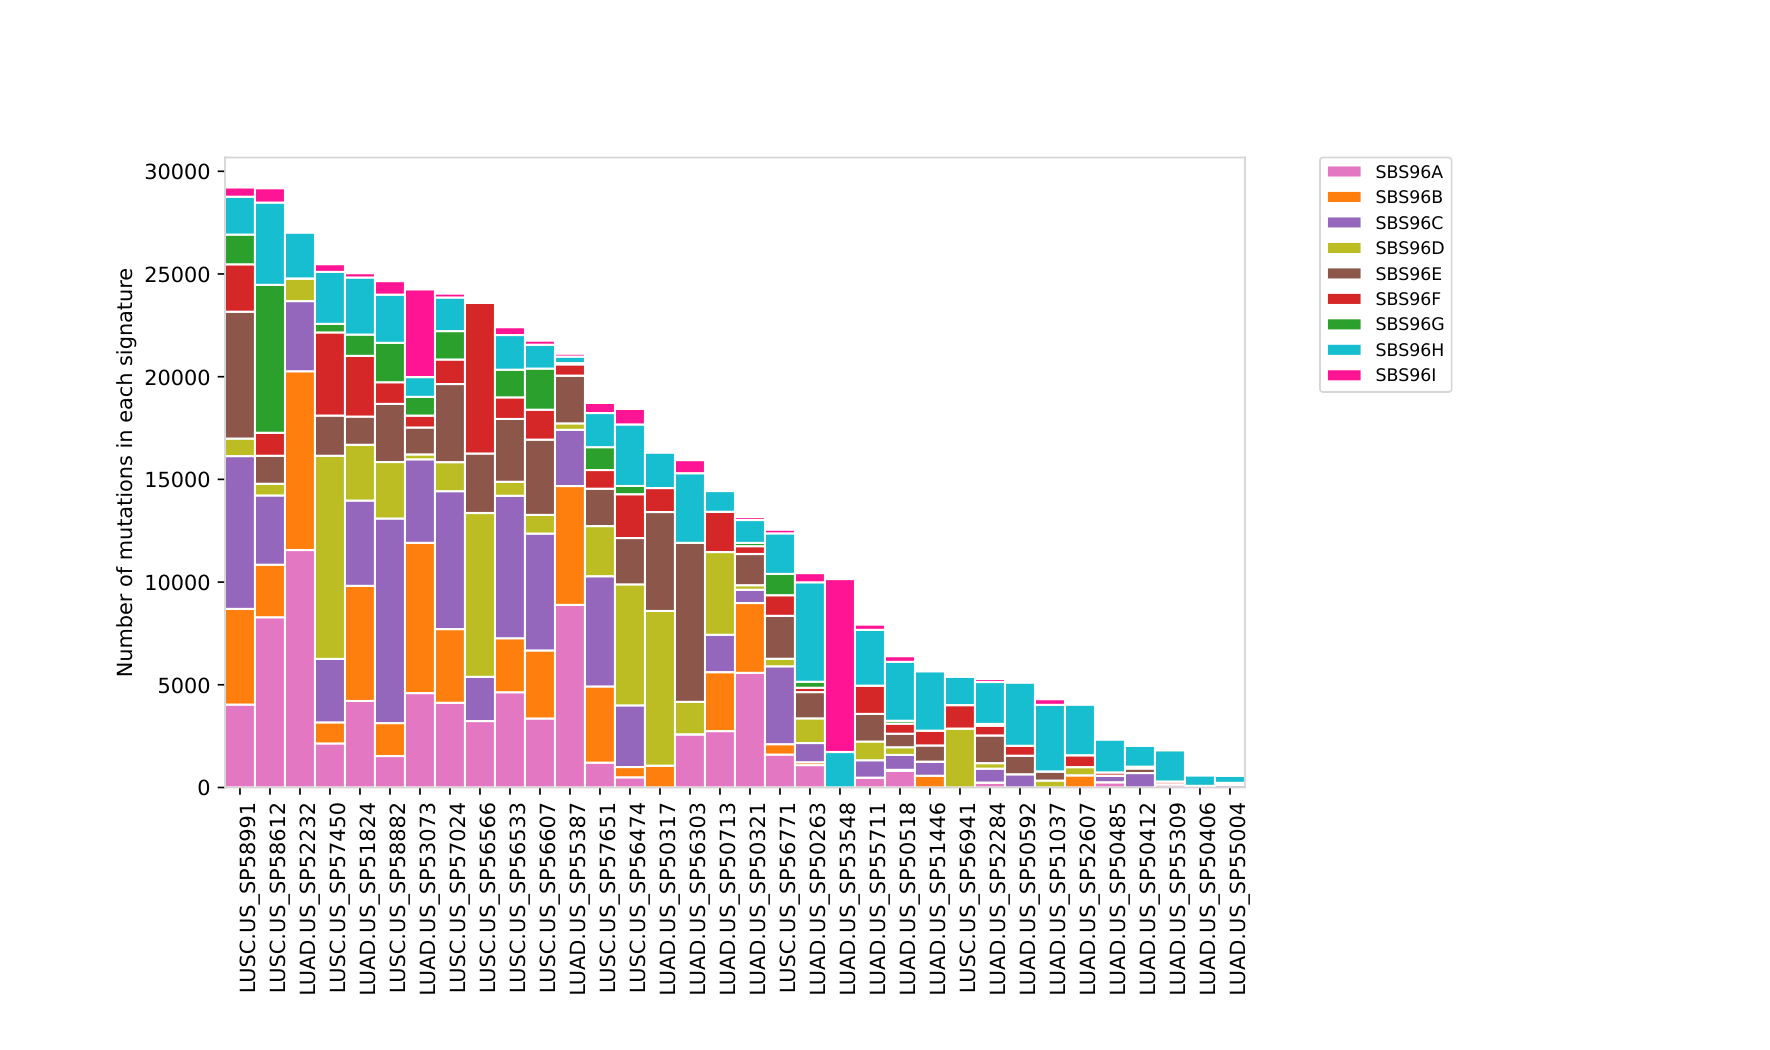

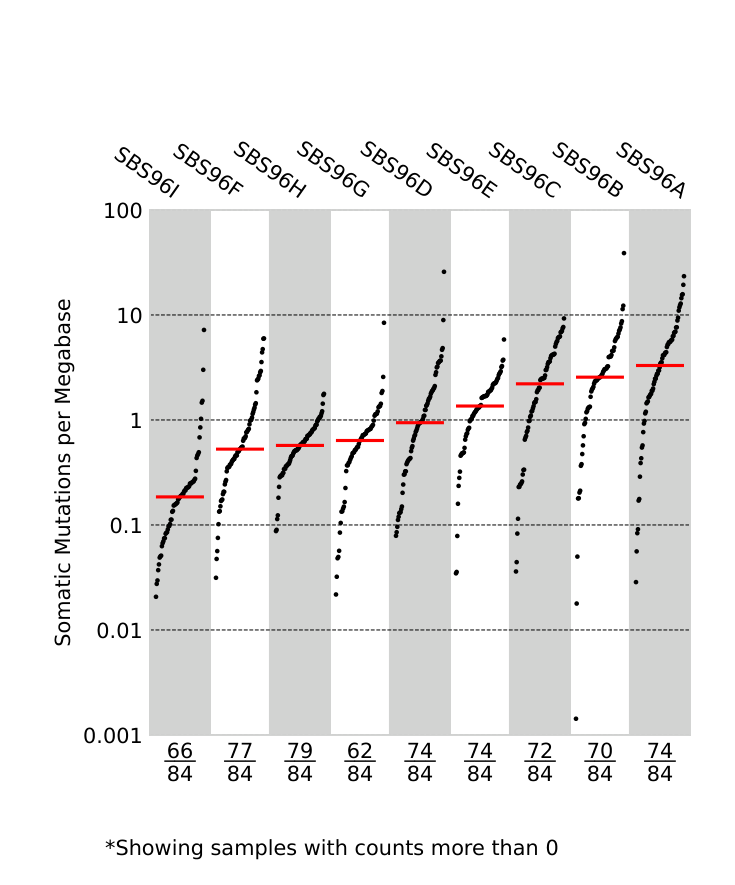

In [8]:
pdfs = [
    base_denovo + r"\Activities\SBS96_De-Novo_Activity_Plots_refit.pdf",
    base_denovo + r"\Activities\SBS96_De-Novo_TMB_plot_refit.pdf",
]

for pdf_path in pdfs:
    doc = fitz.open(pdf_path)
    for page in doc:
        pix = page.get_pixmap(dpi=150)
        display(Image(data=pix.tobytes("png"), format='png'))

# Correlación

## Matriz M

### Entre tumores (columnas)

In [9]:
# Matriz de correlación de M (entre tumores/columnas)
corr_M = np.corrcoef(M.T)  # (146, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (M)')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('Tumor')
plt.colorbar(im, ax=axes[0])

corr_offdiag = corr_M[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tumores (M)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag) > 0.5).mean()*100:.1f}%")

Correlación media: 0.6622
% pares con |corr| > 0.3: 85.6%
% pares con |corr| > 0.5: 70.1%


In [10]:
import seaborn as sns

# Extraer tipo de cáncer del nombre de cada muestra
cancer_types = [col.split(".")[0] for col in M_df.columns]

# Crear paleta de colores por tipo de cáncer
tipos_unicos = list(set(cancer_types))
palette = sns.color_palette("tab20", len(tipos_unicos))
color_map = dict(zip(tipos_unicos, palette))
col_colors = [color_map[t] for t in cancer_types]

# Clustermap
sns.clustermap(pd.DataFrame(corr_M, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

# Leyenda
fig, ax = plt.subplots(figsize=(6, len(tipos_unicos) * 0.4))
for i, (tipo, color) in enumerate(color_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, tipo, va='center', fontsize=9)
ax.set_xlim(0, 3)
ax.axis('off')
plt.tight_layout()
plt.show()

### Entre tipos de mutacion (filas)

In [11]:
# Matriz de correlación de M (entre tipos de mutación/filas)
corr_M_filas = np.corrcoef(M)  # (96, 96)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_M_filas, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tipos de mutación (M)')
axes[0].set_xlabel('Tipo de mutación')
axes[0].set_ylabel('Tipo de mutación')
plt.colorbar(im, ax=axes[0])

corr_offdiag_filas = corr_M_filas[np.triu_indices(n_mut, k=1)]
axes[1].hist(corr_offdiag_filas, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_filas.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_filas.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tipos de mutación (M)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_filas.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_filas) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_filas) > 0.5).mean()*100:.1f}%")

Correlación media: 0.7649
% pares con |corr| > 0.3: 94.1%
% pares con |corr| > 0.5: 86.8%


In [12]:
import seaborn as sns

# Extraer el tipo de sustitución del índice (formato "A[C>A]A")
sust_types = [idx.split('[')[1].split(']')[0] for idx in M_df.index]

tipos_sust = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
palette_sust = sns.color_palette("tab10", 6)
color_map_sust = dict(zip(tipos_sust, palette_sust))
row_colors_sust = [color_map_sust[t] for t in sust_types]

g = sns.clustermap(
    pd.DataFrame(corr_M_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_sust,
    col_colors=row_colors_sust,
    figsize=(14, 14),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.1,
)
g.ax_heatmap.set_title('Clustermap — correlación entre tipos de mutación (M)', pad=12)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map_sust[t], label=t) for t in tipos_sust]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left',
                    bbox_to_anchor=(1.15, 1.1), title='Sustitución')
plt.show()
plt.close('all')

In [13]:
# Extraer las tres componentes de cada contexto (formato "A[C>A]A")
left_base  = [idx[0] for idx in M_df.index]          # letra antes del corchete
sust_type  = [idx.split('[')[1].split(']')[0] for idx in M_df.index]
right_base = [idx[-1] for idx in M_df.index]          # letra después del corchete

# Paletas
bases = ['A', 'C', 'G', 'T']
palette_base = dict(zip(bases, sns.color_palette("Set2", 4)))
palette_sust = dict(zip(['C>A','C>G','C>T','T>A','T>C','T>G'],
                         sns.color_palette("tab10", 6)))

# DataFrame de anotaciones (una columna por característica)
row_colors_df = pd.DataFrame({
    "5' base":    [palette_base[b] for b in left_base],
    "Sust.":      [palette_sust[s] for s in sust_type],
    "3' base":    [palette_base[b] for b in right_base],
}, index=M_df.index)

g = sns.clustermap(
    pd.DataFrame(corr_M_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    figsize=(15, 15),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.08,
)
g.ax_heatmap.set_title('Clustermap tipos de mutación — anotado por contexto', pad=12)

# Leyenda bases
from matplotlib.patches import Patch
leg1 = [Patch(facecolor=palette_base[b], label=b) for b in bases]
leg2 = [Patch(facecolor=palette_sust[s], label=s) for s in ['C>A','C>G','C>T','T>A','T>C','T>G']]
l1 = g.ax_heatmap.legend(handles=leg1, title="Base 5'/3'",
                          loc='upper left', bbox_to_anchor=(1.18, 1.05))
g.ax_heatmap.add_artist(l1)
g.ax_heatmap.legend(handles=leg2, title="Sustitución",
                    loc='upper left', bbox_to_anchor=(1.18, 0.65))
plt.show()
plt.close('all')

## Matriz Residuos

In [14]:
S = S_denovo_df.values.astype(float)
A = A_denovo_df.values.T.astype(float)
M_hat = S @ A
U = pd.DataFrame(M - M_hat, index=M_df.index, columns=M_df.columns)
Uv = U.values

### Entre tumores (columnas)

In [15]:
# Correlación entre tumores (columnas)

corr_U = np.corrcoef(Uv.T)  # (146, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_U, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (U)')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('Tumor')
plt.colorbar(im, ax=axes[0])

corr_offdiag_U = corr_U[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag_U, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_U.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_U.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tumores (U)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_U.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_U) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_U) > 0.5).mean()*100:.1f}%")

Correlación media: -0.0059
% pares con |corr| > 0.3: 13.4%
% pares con |corr| > 0.5: 1.1%


In [16]:
# Clustermap tumores con color por tipo de cáncer
sns.clustermap(pd.DataFrame(corr_U, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

fig, ax = plt.subplots(figsize=(6, len(tipos_unicos) * 0.4))
for i, (tipo, color) in enumerate(color_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, tipo, va='center', fontsize=9)
ax.set_xlim(0, 3)
ax.axis('off')
plt.tight_layout()
plt.show()
plt.close('all')

### Entre tipos de mutación (filas)

In [17]:
# Correlación entre tipos de mutación (filas)
corr_U_filas = np.corrcoef(Uv)  # (96, 96)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_U_filas, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tipos de mutación (U)')
axes[0].set_xlabel('Tipo de mutación')
axes[0].set_ylabel('Tipo de mutación')
plt.colorbar(im, ax=axes[0])

corr_offdiag_U_filas = corr_U_filas[np.triu_indices(n_mut, k=1)]
axes[1].hist(corr_offdiag_U_filas, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_U_filas.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_U_filas.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tipos de mutación (U)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_U_filas.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_U_filas) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_U_filas) > 0.5).mean()*100:.1f}%")

Correlación media: 0.0012
% pares con |corr| > 0.3: 20.4%
% pares con |corr| > 0.5: 3.8%


In [18]:
# Clustermap tipos de mutación anotado
g = sns.clustermap(
    pd.DataFrame(corr_U_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    figsize=(15, 15),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.08,
)
g.ax_heatmap.set_title('Clustermap tipos de mutación (U) — anotado por contexto', pad=12)
l1 = g.ax_heatmap.legend(handles=leg1, title="Base 5'/3'",
                          loc='upper left', bbox_to_anchor=(1.18, 1.05))
g.ax_heatmap.add_artist(l1)
g.ax_heatmap.legend(handles=leg2, title="Sustitución",
                    loc='upper left', bbox_to_anchor=(1.18, 0.65))
plt.show()
plt.close('all')

# Cálculo de los Residuos

In [19]:
S = S_denovo_df.values.astype(float)      # (96, 8)
A = A_denovo_df.values.T.astype(float)    # (8, 146)

M_hat = S @ A
U = pd.DataFrame(M - M_hat, index=M_df.index, columns=M_df.columns)

print(f"Media residuos (≈ 0): {U.values.mean():.4f}")
print(f"RMSE: {np.sqrt(np.mean(U.values**2)):.4f}")
U

Media residuos (≈ 0): -0.0000
RMSE: 43.4147


,LUAD.US_SP50827,LUAD.US_SP50263,LUAD.US_SP50317,LUAD.US_SP54113,LUSC.US_SP56537,LUAD.US_SP50406,LUSC.US_SP57586,LUAD.US_SP51824,LUAD.US_SP55387,LUAD.US_SP52779,...,LUAD.US_SP52667,LUSC.US_SP57450,LUSC.US_SP57846,LUSC.US_SP58612,LUSC.US_SP56821,LUAD.US_SP51446,LUAD.US_SP50592,LUAD.US_SP53073,LUSC.US_SP58882,LUSC.US_SP57189
MutationType,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,-11.361978,-9.378414,-7.411063,-75.086095,-2.075743,2.003264,30.271359,-54.140593,73.280851,35.723142,...,-145.449675,-7.616551,-39.164556,-20.689857,-21.275360,12.867603,-0.732645,25.569487,-36.371585,79.422018
A[C>A]C,85.909605,-13.174543,10.889210,-89.756775,21.484732,-4.683791,-3.132084,-16.226287,-2.855027,-38.779402,...,-51.289356,-17.105517,15.984831,17.572093,-24.108012,16.926196,-15.943698,56.588876,-10.906956,-12.350863
A[C>A]G,25.525185,2.567537,-2.958197,-5.295822,27.231156,-1.984408,10.801518,-5.204261,-11.585544,64.162893,...,-27.218379,8.486302,48.448588,8.767152,-13.726085,2.775590,4.532298,-6.993140,-2.167889,-18.173343
A[C>A]T,3.579390,-4.916166,17.562262,-237.002375,9.960181,0.206851,6.334265,-14.236871,49.053656,7.537442,...,-83.012394,-7.635087,-14.308721,-77.918548,-4.477822,11.872027,-1.169802,5.616923,7.754196,-135.506483
A[C>G]A,-2.360866,29.637655,23.289514,52.455196,-4.134029,1.373545,45.187007,-9.203905,27.427799,-72.408870,...,-53.379402,11.247969,-25.537768,-16.041791,15.991967,-8.450902,-4.777489,-34.155290,-59.663416,137.852662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T[T>C]T,30.599495,-14.271357,6.148719,-84.759670,-23.136608,-1.612372,31.102980,-24.928254,-5.057932,-5.597889,...,1.408323,32.805631,-36.675568,-17.962969,-3.713742,-9.178827,11.775802,-4.373147,75.984907,-8.848224
T[T>G]A,9.023497,-3.488085,-0.102770,-27.475741,-7.523839,-0.070442,26.506566,-7.475340,-9.840150,21.408543,...,8.480229,6.921031,-24.493595,-22.161995,2.852945,-1.408258,1.680042,-34.584325,-3.936709,-32.814015
T[T>G]C,-11.452090,1.788619,0.012378,-25.077831,-8.280196,-1.185020,0.649576,-4.305092,7.075390,-0.658956,...,10.763730,-1.255240,-1.792897,-3.060793,-10.465940,-3.212510,-3.795361,-32.973803,13.538886,-46.893797


# Análisis de varianza

In [20]:
p = S.shape[1] * n_mut + S.shape[1] * n_tum
dof = n_mut * n_tum - p

sigma2_global = np.sum(U.values**2) / dof
sigma2_col = np.var(U.values, axis=0, ddof=1)
sigma2_row = np.var(U.values, axis=1, ddof=1)

print(f"σ² global:  {sigma2_global:.2f}")
print(f"\nσ² por columnas (tumores):")
print(f"  min: {sigma2_col.min():.2f},  max: {sigma2_col.max():.2f},  media: {sigma2_col.mean():.2f}")
print(f"  Ratio max/min: {sigma2_col.max()/sigma2_col.min():.1f}x")
print(f"\nσ² por filas (tipos de mutación):")
print(f"  min: {sigma2_row.min():.2f},  max: {sigma2_row.max():.2f},  media: {sigma2_row.mean():.2f}")
print(f"  Ratio max/min: {sigma2_row.max()/sigma2_row.min():.1f}x")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(n_tum), sigma2_col, color='steelblue', alpha=0.7)
axes[0].axhline(sigma2_global, color='red', linestyle='--', linewidth=2,
                label=f'σ² global = {sigma2_global:.0f}')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('σ²')
axes[0].set_title('σ² por columna (tumor)')
axes[0].legend()

axes[1].bar(range(n_mut), sigma2_row, color='darkorange', alpha=0.7)
axes[1].axhline(sigma2_global, color='red', linestyle='--', linewidth=2,
                label=f'σ² global = {sigma2_global:.0f}')
axes[1].set_xlabel('Tipo de mutación')
axes[1].set_ylabel('σ²')
axes[1].set_title('σ² por fila (tipo de mutación)')
axes[1].legend()

plt.tight_layout()
plt.show()

σ² global:  2358.68

σ² por columnas (tumores):
  min: 6.54,  max: 40069.92,  media: 1904.68
  Ratio max/min: 6122.7x

σ² por filas (tipos de mutación):
  min: 24.82,  max: 17158.92,  media: 1901.80
  Ratio max/min: 691.2x


# Variabilidad

In [21]:
Uv = U.values  # numpy array limpio

media_filas = M.mean(axis=1)

VT  = np.sum((M    - media_filas[:, None])**2)
VE  = np.sum((M_hat - media_filas[:, None])**2)
VNE = np.sum((Uv   - Uv.mean(axis=1)[:, None])**2)

print(f"VT  = {VT:.2f}")
print(f"VE  = {VE:.2f}")
print(f"VNE = {VNE:.2f}")
print(f"\n% variabilidad explicada:    {100 * VE / VT:.2f}%")
print(f"% variabilidad no explicada: {100 * VNE / VT:.2f}%")

SS_resid  = np.sum(Uv**2)
SS_total  = np.sum((M - M.mean())**2)
SS_expl   = SS_total - SS_resid

R2 = SS_expl / SS_total

print(f"SS_total  = {SS_total:.2e}")
print(f"SS_expl   = {SS_expl:.2e}")
print(f"SS_resid  = {SS_resid:.2e}")
print(f"\nR² = {R2:.4f}  ({100*R2:.2f}% variabilidad explicada)")
print(f"Residuo relativo (||U||/||M||): {np.linalg.norm(Uv)/np.linalg.norm(M):.4f}")

VT  = 3220943407.69
VE  = 3186864826.91
VNE = 15153531.82

% variabilidad explicada:    98.94%
% variabilidad no explicada: 0.47%
SS_total  = 4.48e+09
SS_expl   = 4.47e+09
SS_resid  = 1.52e+07

R² = 0.9966  (99.66% variabilidad explicada)
Residuo relativo (||U||/||M||): 0.0504


# BOOTSTRAP 

In [22]:
from scipy.optimize import nnls

B = 1000  # número de iteraciones bootstrap
S = S_denovo_df.values.astype(float)  # (96, 8) — fija
n_sig = S.shape[1]

A_boot = np.zeros((B, n_sig, n_tum))  # (1000, 8, 146)

np.random.seed(SEED)

for b in range(B):
    if b % 100 == 0:
        print(f"Bootstrap {b}/{B}...")
    
    # Remuestrear cada tumor por separado
    M_star = np.zeros_like(M)
    for j in range(n_tum):
        counts = M[:, j].astype(int)
        total = counts.sum()
        probs = counts / total
        M_star[:, j] = np.random.multinomial(total, probs)
    
    # Fitting: S fija, encontrar A* con NNLS
    for j in range(n_tum):
        a_star, _ = nnls(S, M_star[:, j])
        A_boot[b, :, j] = a_star

print("Bootstrap completado")

Bootstrap 0/1000...
Bootstrap 100/1000...
Bootstrap 200/1000...
Bootstrap 300/1000...
Bootstrap 400/1000...
Bootstrap 500/1000...
Bootstrap 600/1000...
Bootstrap 700/1000...
Bootstrap 800/1000...
Bootstrap 900/1000...
Bootstrap completado


In [23]:
# Intervalos de confianza al 95%
A_mean  = A_boot.mean(axis=0)                                  # (8, 146)
A_lower = np.percentile(A_boot, 2.5,  axis=0)                 # (8, 146)
A_upper = np.percentile(A_boot, 97.5, axis=0)                 # (8, 146)

print("A_mean shape:", A_mean.shape)
print("IC calculados")

A_mean shape: (9, 84)
IC calculados


In [24]:
# 1. Heatmap de A_mean — qué firmas dominan en qué tumores
sig_names = S_denovo_df.columns.tolist()
tumor_names = M_df.columns.tolist()

fig, ax = plt.subplots(figsize=(20, 5))
im = ax.imshow(A_mean, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(n_sig))
ax.set_yticklabels(sig_names)
ax.set_xlabel('Tumor')
ax.set_title('Actividades medias bootstrap (A_mean)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close('all')

In [25]:
# 2. Anchura del IC — qué tumores/firmas tienen más incertidumbre
IC_width = A_upper - A_lower  # (8, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(IC_width, aspect='auto', cmap='Blues')
axes[0].set_yticks(range(n_sig))
axes[0].set_yticklabels(sig_names)
axes[0].set_xlabel('Tumor')
axes[0].set_title('Anchura IC 95% por firma y tumor')
plt.colorbar(im, ax=axes[0])

# Anchura media por firma
axes[1].barh(sig_names, IC_width.mean(axis=1), color='steelblue', alpha=0.8)
axes[1].set_xlabel('Anchura media IC 95%')
axes[1].set_title('Incertidumbre media por firma')

plt.tight_layout()
plt.show()
plt.close('all')

In [26]:
# 3. Comparar A_mean bootstrap vs A original
A_orig = A_denovo_df.values.T.astype(float)  # (8, 146)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, sig in enumerate(sig_names):
    axes[i].scatter(A_orig[i], A_mean[i], alpha=0.6, s=20, color='steelblue')
    lim = max(A_orig[i].max(), A_mean[i].max()) * 1.05
    axes[i].plot([0, lim], [0, lim], 'r--', linewidth=1)
    axes[i].set_title(sig)
    axes[i].set_xlabel('A original')
    axes[i].set_ylabel('A_mean bootstrap')

plt.suptitle('A original vs A_mean bootstrap', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')

In [27]:
sig_idx = 0

orden = np.argsort(A_mean[sig_idx])[::-1]

err_low  = (A_mean[sig_idx] - A_lower[sig_idx]).clip(0)[orden]
err_high = (A_upper[sig_idx] - A_mean[sig_idx]).clip(0)[orden]

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(range(n_tum), A_mean[sig_idx][orden], color='steelblue', alpha=0.8)
ax.errorbar(range(n_tum),
            A_mean[sig_idx][orden],
            yerr=[err_low, err_high],
            fmt='none', color='black', capsize=2, linewidth=0.8)
ax.set_xlabel('Tumor (ordenado)')
ax.set_ylabel('Actividad')
ax.set_title(f'Actividad {sig_names[sig_idx]} por tumor ± IC 95%')
plt.tight_layout()
plt.show()
plt.close('all')

In [28]:
sig_idx = 0
top_n = 30

orden = np.argsort(A_mean[sig_idx])[::-1][:top_n]

err_low  = (A_mean[sig_idx] - A_lower[sig_idx]).clip(0)[orden]
err_high = (A_upper[sig_idx] - A_mean[sig_idx]).clip(0)[orden]
labels = [M_df.columns[i].split(".")[0] for i in orden]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(top_n), A_mean[sig_idx][orden], color='steelblue', alpha=0.8, width=0.6)
ax.errorbar(range(top_n),
            A_mean[sig_idx][orden],
            yerr=[err_low, err_high],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.set_xticks(range(top_n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Actividad')
ax.set_title(f'Top {top_n} tumores — actividad {sig_names[sig_idx]} ± IC 95%')
plt.tight_layout()
plt.show()
plt.close('all')

In [29]:
cancer_types = [col.split(".")[0] for col in M_df.columns]
from collections import Counter
counts = Counter(cancer_types)
for tipo, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"{tipo}: {n}")

LUSC: 47
LUAD: 37
